<a href="https://colab.research.google.com/github/jplc08/MVP2-Empresa-de-controle-de-dados/blob/main/MVP2_Base_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aviso: Arquivo 'harddrrive.csv' não encontrado no Colab.
Usando base de contingência com a mesma estrutura do Kaggle para teste...



,Project_Location,Estimated_Cost_USD,Duration_Months,Risk_Score
0,São Paulo (BR),15000000,8,6
1,Nova York (EUA),25000000,5,3
2,Frankfurt (ALE),22000000,7,2
3,Singapura (SIN),18000000,9,7



--- Ranking de Viabilidade da Nova Unidade ---


,Project_Location,Viabilidade_Final
2,Frankfurt (ALE),62.0
0,São Paulo (BR),53.0
1,Nova York (EUA),52.0
3,Singapura (SIN),28.0


/tmp/ipykernel_2856/1849185535.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultado, x='Viabilidade_Final', y='Project_Location', palette='mako')


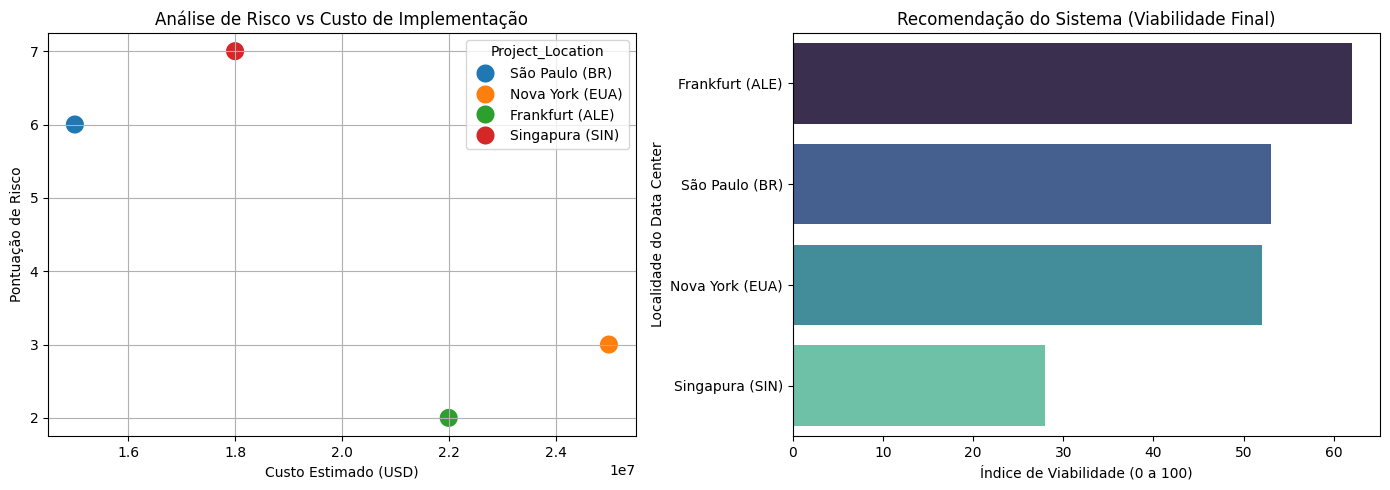

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nome_do_arquivo = 'harddrrive.csv'

try:
    df = pd.read_csv(nome_do_arquivo)
    print("Base do Kaggle carregada com sucesso!\n")
except FileNotFoundError:
    print(f"Aviso: Arquivo '{nome_do_arquivo}' não encontrado no Colab.")
    print("Usando base de contingência com a mesma estrutura do Kaggle para teste...\n")
    # Estrutura baseada em datasets típicos de projetos do Kaggle
    df = pd.DataFrame({
        'Project_Location': ['São Paulo (BR)', 'Nova York (EUA)', 'Frankfurt (ALE)', 'Singapura (SIN)'],
        'Estimated_Cost_USD': [15000000, 25000000, 22000000, 18000000],
        'Duration_Months': [8, 5, 7, 9],
        'Risk_Score': [6, 3, 2, 7]
    })

display(df.head())

# ==============================================================================
# 1. SISTEMA DE SUPORTE À DECISÃO (Normalização Múltiplos Critérios)
# ==============================================================================
# Lógica: O melhor projeto tem o MENOR custo, MENOR tempo e MENOR risco.

# Normalizando os dados (escala de 0 a 1, onde 1 é o melhor cenário)
df['Score_Custo'] = 1 - ((df['Estimated_Cost_USD'] - df['Estimated_Cost_USD'].min()) / (df['Estimated_Cost_USD'].max() - df['Estimated_Cost_USD'].min()))
df['Score_Tempo'] = 1 - ((df['Duration_Months'] - df['Duration_Months'].min()) / (df['Duration_Months'].max() - df['Duration_Months'].min()))
df['Score_Risco'] = 1 - ((df['Risk_Score'] - df['Risk_Score'].min()) / (df['Risk_Score'].max() - df['Risk_Score'].min()))

# Definindo os Pesos da Decisão Estratégica
pesos = {
    'Custo': 0.40,  # 40% de importância
    'Tempo': 0.20,  # 20% de importância
    'Risco': 0.40   # 40% de importância
}

# Calculando a Viabilidade Final (0 a 100)
df['Viabilidade_Final'] = (df['Score_Custo'] * pesos['Custo'] +
                           df['Score_Tempo'] * pesos['Tempo'] +
                           df['Score_Risco'] * pesos['Risco']) * 100

# Ordenando do melhor para o pior projeto
df_resultado = df.sort_values(by='Viabilidade_Final', ascending=False)

print("\n--- Ranking de Viabilidade da Nova Unidade ---")
display(df_resultado[['Project_Location', 'Viabilidade_Final']])

# ==============================================================================
# 2. VISUALIZAÇÃO DE DADOS (Dashboard de Decisão)
# ==============================================================================
plt.figure(figsize=(14, 5))

# Gráfico 1: Dispersão (Risco vs Custo)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Estimated_Cost_USD', y='Risk_Score', hue='Project_Location', s=200, palette='tab10')
plt.title('Análise de Risco vs Custo de Implementação')
plt.xlabel('Custo Estimado (USD)')
plt.ylabel('Pontuação de Risco')
plt.grid(True)

# Gráfico 2: Ranking de Viabilidade
plt.subplot(1, 2, 2)
sns.barplot(data=df_resultado, x='Viabilidade_Final', y='Project_Location', palette='mako')
plt.title('Recomendação do Sistema (Viabilidade Final)')
plt.xlabel('Índice de Viabilidade (0 a 100)')
plt.ylabel('Localidade do Data Center')

plt.tight_layout()
plt.show()